# Analytische oplossing voor punt onder schrijf op de bodem met uniforme infiltratie op grotere afstand of uniforme verticale neerwaartse stroming op diepte


In [60]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom
from tools.fdm.src import mfgrid, fdm3Blom

print("=== Current Session ===")
print("os.getcwd():", os.getcwd())
print("sys.executable: ", sys.executable)
print("sys.path:")
for p in sys.path:
    print(p)
print("=======================")


NOTEBOOK_NAME = "ARK_profiles.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home   = os.path.join(self.rws, "src")
        self.images = os.path.normpath(os.path.join(self.home, '../images'))
        self.data   = os.path.normpath(os.path.join(self.home, '../data'))
        self.pb_data = os.path.normpath(os.path.join(self.data, 'peilbuizen'))
        self.pb_imag = os.path.normpath(os.path.join(self.images, 'peilbuizen'))
        self.gis = os.path.normpath(os.path.join(self.data, 'Geotiff'))
        
dirs = Dirs()

print("Project directory namespace:")
descr(dirs)


raai_colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # cyan
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green    
]

leg_colors = [
    "#0000FF",  # blue
    "#FF0000",  # red
    "#00FF00",  # green
    "#000033",  # dark navy
    "#FF00B6",  # magenta
    "#005300",  # dark green
    "#FFD300",  # yellow
    "#009FFF",  # sky blue
    "#9A4D42",  # brown
    "#00FFBE",  # turquoise
    "#783FC1",  # purple
    "#1F9698",  # teal
    "#FFACFD",  # light pink
    "#B1CC71",  # olive
    "#F1085C",  # crimson
    "#FE8F42",  # orange
    "#DD00FF",  # violet
    "#201A01",  # dark brown
    "#720055",  # dark magenta
    "#766C95"   # slate gray
]


=== Current Session ===
os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys.executable:  /Users/Theo/Development/python/mf6_tools/mf6lab/.venv/bin/python
sys.path:
/Users/Theo/GRWMODELS/python/tools
./modules/
/Users/Theo/GRWMODELS/python/bootstraps
/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages
__editable__.mf6lab-0.1.finder.__path_hook__
__editable__.tools-0.1.finder.__path_hook__
NOTEBOOK_NAME = 'ARK_profiles.ipynb'
Project directory namespace:
rws                  /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/
home                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src
images               /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK

# Ondoorlatende schijf op aquifer met verticale infiltratie

axial==True so that y coordinates and ky are ignored
            and x stands for r, so that all x coordinates must be >= 0.
No outer iterations needed.

===== Water balance of the entire model =====
Model grid = (60, 1, 71)

Sum over all nodal flows should be zero:
Total net in Q1     = 8.5991e-08 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =       -1570.796 m3/d
Fixed heads         QFH  =        1570.796 m3/d

Total water balance of this model
Q1 (internal)            =           0.000 m3/d, total internal flow
Q2 (boundaries)          =          -0.000 m3/d, total from boundaries
===== end of water balance =====



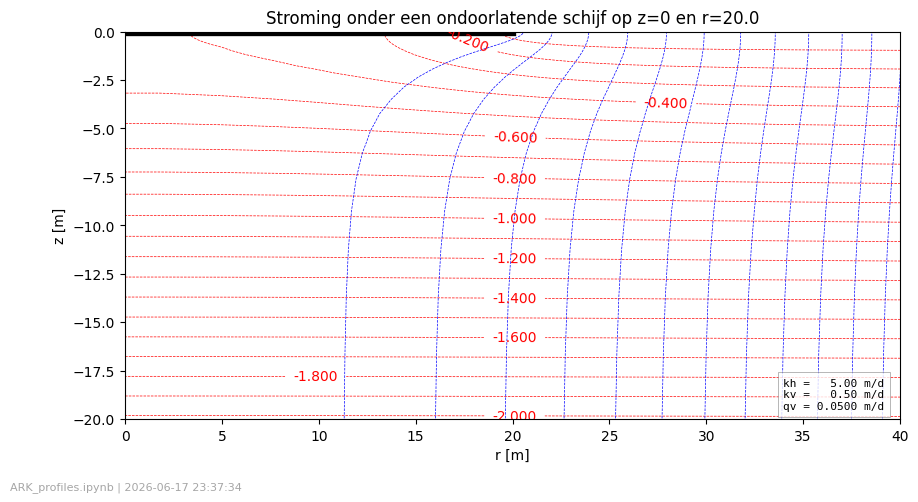

In [217]:

R, R_model = 20., 100
htop, hbot = 1.0, -1.0
kh, kv = 5., 0.5
dphi, dpsi = 0.2, 20

r = np.hstack((0.02, R - np.logspace(-2, np.log10(R), 40)[::-1], R + np.logspace(-2, np.log10(R_model - R), 30), R_model-0.01))
z = np.unique(np.hstack((0,  -np.logspace(-2, 3, 60))))[::-1]

gr = mfgrid.Grid(r, None, z, axial=True)

ir = np.searchsorted(gr.x, R)  - 1
iz = np.searchsorted(-gr.zm, 0)
disk = (gr.ZM == gr.zm[iz]) & (gr.Xm < R)

K = (gr.const(kh), gr.const(kh), gr.const(kv))

HI = gr.const(0.)
HI[-1] = hbot

# --- Uniform background flow along 
qz = 0.05 # 50 mm/d

# --- Total extraction to stop qz at disk
Q = -qz * np.pi * R ** 2

# --- Fixed flow (of disk)

FQ = gr.const(0.)
iR = np.searchsorted(gr.x + 0.01, R)
FQ[-1,0,:] = -qz * np.pi * np.array([(gr.x[i+1] ** 2 - gr.x[i] ** 2) for i in range(gr.nx)])

IBOUND = gr.const(1, dtype=int)
IBOUND[0, :, gr.xm > R] = -1
# IBOUND[-1] = -1

mdl = fdm3Blom.Fdm3(gr, K=K, HI=HI, FQ=FQ, IBOUND=IBOUND)
out = mdl.simulate()

psi =  np.cumsum(np.hstack((out['Qz'][:,0,:], np.zeros((gr.nz - 1, 1))))[:,::-1], axis=1)[:,::-1]
Xpsi, Zpsi = np.meshgrid(gr.x, gr.z[1:-1])

out['psi'] = psi


xlim = (0, 2 * R)
ylim = (-R, 0)

mask_phi = gr.ZM > ylim[0] - 10
mask_psi = np.zeros(out['psi'].shape, dtype=bool)
mask_psi[(Xpsi < 2 * xlim[1])] = True

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_title(f"Stroming onder een ondoorlatende schijf op z=0 en r={R}")
ax.set(xlabel='r [m]', ylabel='z [m]')

ax.plot(gr.XM[disk], gr.ZM[disk], 'k', lw=6, label='disk', zorder=3)

phi_min, phi_max = np.floor(out['Phi'][mask_phi].min() * 100)/100, np.ceil(out['Phi'][mask_phi].max() * 100) / 100
psi_min, psi_max = np.floor(out['psi'][mask_psi].min() * 100)/100, np.ceil(out['psi'][mask_psi].max() * 100) / 100

phi_levels = np.arange(phi_min, 0 * phi_max + 2 * dphi, dphi)
phi_levels = np.arange(-2, 0.1, 0.1)

psi_levels = np.arange(psi_min, psi_max + dpsi, dpsi)

Cphi = ax.contour(gr.XM[:,0,:], gr.ZM[:,0,:], out['Phi'][:,0,:], levels=phi_levels, colors='r', linewidths=0.5)
Cpsi = ax.contour(Xpsi, Zpsi, out['psi'], levels=psi_levels, colors='b', linewidths=0.5)
skip=2
ax.clabel(Cphi, levels=phi_levels[::skip], fmt="%0.3f", use_clabeltext=True, inline_spacing=-10)
# ax.clabel(Cpsi, levels=psi_levels[::5], fmt="%.0f", use_clabeltext=True, inline_spacing=-10)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal')

txt = [
     f"kh = {kh:6.2f} m/d",
     f"kv = {kv:6.2f} m/d",
     f"qv = {qz:6.4f} m/d"
     ]
ax.text(0.98, 0.02, '\n'.join(txt),        
        transform=ax.transAxes,
        ha='right', va='bottom',
        family='monospace',
        fontsize=8,
        bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

logo(fig, NOTEBOOK_NAME)
path = os.path.join(dirs.images, f"stroming_onder_schijf_{R:.0f}m.pdf")
fig.savefig(path)

# phi_min, phi_max, levels


# Zelfde in 2D (onderlatende strook)

No outer iterations needed.

===== Water balance of the entire model =====
Model grid = (60, 1, 71)

Sum over all nodal flows should be zero:
Total net in Q1     = -1.6431e-08 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =          -5.000 m3/d
Fixed heads         QFH  =           5.000 m3/d

Total water balance of this model
Q1 (internal)            =          -0.000 m3/d, total internal flow
Q2 (boundaries)          =          -0.000 m3/d, total from boundaries
===== end of water balance =====



/var/folders/90/m51x_b713y561gzh2kzy18d00000gq/T/ipykernel_83511/1693356067.py:67: UserWarning: The following kwargs were not used by contour: 'color'
  Cpsi = ax.contour(Xpsi, Zpsi, out['psi'], levels=psi_levels, color='b', linewidths=0.5)


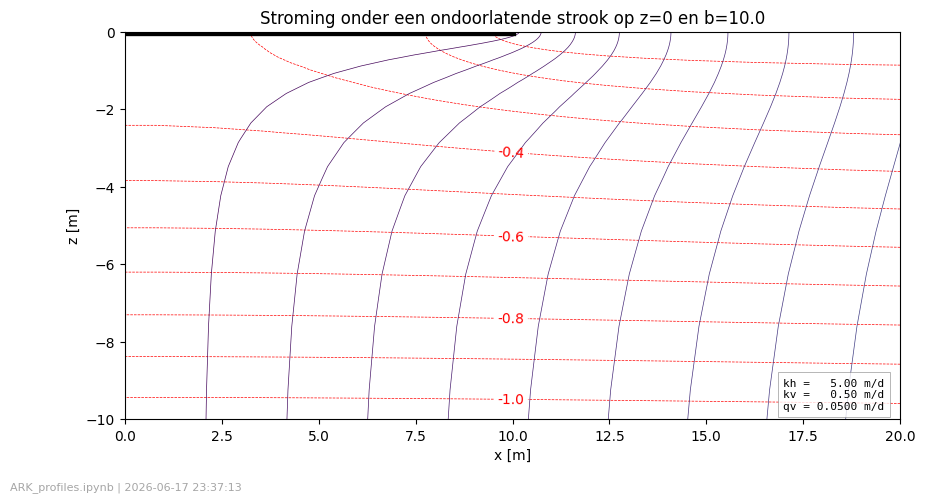

In [216]:
b, b_model = 10., 100
htop, hbot = 1.0, -1.0
kh, kv = 5., 0.5
dphi, dpsi = 0.1, 0.1

x = np.hstack((0.02, b - np.logspace(-2, np.log10(b), 40)[::-1], b + np.logspace(-2, np.log10(b_model - b), 30), b_model-0.01))
z = np.unique(np.hstack((0,  -np.logspace(-2, 3, 60))))[::-1]

gr = mfgrid.Grid(x, None, z, axial=False)

ir = np.searchsorted(gr.x, b)  - 1
iz = np.searchsorted(-gr.zm, 0)
disk = (gr.ZM == gr.zm[iz]) & (gr.Xm < b)

K = (gr.const(kh), gr.const(kh), gr.const(kv))

HI = gr.const(0.)
HI[-1] = hbot

# --- Uniform background flow along 
qz = 0.05 # 50 mm/d

# --- Total extraction to stop qz at disk
Q = -qz * b

# --- Fixed flow (of disk)

FQ = gr.const(0.)
iR = np.searchsorted(gr.x + 0.01, b)
FQ[-1,0,:] = -qz * gr.dx

IBOUND = gr.const(1, dtype=int)
IBOUND[0, :, gr.xm > b] = -1
# IBOUND[-1] = -1

mdl = fdm3Blom.Fdm3(gr, K=K, HI=HI, FQ=FQ, IBOUND=IBOUND)
out = mdl.simulate()

psi =  np.cumsum(np.hstack((out['Qz'][:,0,:], np.zeros((gr.nz - 1, 1))))[:,::-1], axis=1)[:,::-1]
Xpsi, Zpsi = np.meshgrid(gr.x, gr.z[1:-1])

out['psi'] = psi

xlim = (0, 2 * b)
ylim = (-b, 0)

mask_phi = gr.ZM > ylim[0] - 10
mask_psi = np.zeros(out['psi'].shape, dtype=bool)
mask_psi[(Xpsi < 2 * xlim[1])] = True

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_title(f"Stroming onder een ondoorlatende strook op z=0 en b={b}")
ax.set(xlabel='x [m]', ylabel='z [m]')

ax.plot(gr.XM[disk], gr.ZM[disk], 'k', lw=6, label='disk', zorder=3)

phi_min, phi_max = np.floor(out['Phi'][mask_phi].min() * 100)/100, np.ceil(out['Phi'][mask_phi].max() * 100) / 100
psi_min, psi_max = np.floor(out['psi'][mask_psi].min() * 100)/100, np.ceil(out['psi'][mask_psi].max() * 100) / 100

phi_levels = np.arange(phi_min, 0 * phi_max + 2 * dphi, dphi)
phi_levels = np.arange(psi_min, psi_max, dpsi)

phi_levels = np.arange(-3, 0, dphi)
psi_levels = np.arange(-5, 0, dpsi)

Cphi = ax.contour(gr.XM[:,0,:], gr.ZM[:,0,:], out['Phi'][:,0,:], levels=phi_levels, colors='r', linewidths=0.5)
Cpsi = ax.contour(Xpsi, Zpsi, out['psi'], levels=psi_levels, color='b', linewidths=0.5)
skip=2
ax.clabel(Cphi, levels=phi_levels[::skip], fmt="%.1f", use_clabeltext=True, inline_spacing=-10)
# ax.clabel(Cpsi, levels=psi_levels[::5], fmt="%.1f", use_clabeltext=True, inline_spacing=-10)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal')

txt = [
     f"kh = {kh:6.2f} m/d",
     f"kv = {kv:6.2f} m/d",
     f"qv = {qz:6.4f} m/d"
     ]
ax.text(0.98, 0.02, '\n'.join(txt),        
        transform=ax.transAxes,
        ha='right', va='bottom',
        family='monospace',
        fontsize=8,
        bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

logo(fig, NOTEBOOK_NAME)
path = os.path.join(dirs.images, f"stroming_onder_strook_{b:.0f}m")
fig.savefig(path)
# phi_min, phi_max, levels



In [208]:
x

array([2.00000000e-02, 0.00000000e+00, 1.62322360e+00, 2.98296171e+00,
       4.12198393e+00, 5.07611737e+00, 5.87537362e+00, 6.54489271e+00,
       7.10573388e+00, 7.57553798e+00, 7.96908238e+00, 8.29874572e+00,
       8.57489733e+00, 8.80622336e+00, 9.00000000e+00, 9.16232236e+00,
       9.29829617e+00, 9.41219839e+00, 9.50761174e+00, 9.58753736e+00,
       9.65448927e+00, 9.71057339e+00, 9.75755380e+00, 9.79690824e+00,
       9.82987457e+00, 9.85748973e+00, 9.88062234e+00, 9.90000000e+00,
       9.91623224e+00, 9.92982962e+00, 9.94121984e+00, 9.95076117e+00,
       9.95875374e+00, 9.96544893e+00, 9.97105734e+00, 9.97575538e+00,
       9.97969082e+00, 9.98298746e+00, 9.98574897e+00, 9.98806223e+00,
       9.99000000e+00, 1.00100000e+01, 1.00136884e+01, 1.00187373e+01,
       1.00256484e+01, 1.00351085e+01, 1.00480580e+01, 1.00657838e+01,
       1.00900476e+01, 1.01232610e+01, 1.01687247e+01, 1.02309574e+01,
       1.03161441e+01, 1.04327512e+01, 1.05923678e+01, 1.08108577e+01,
      

In [198]:
out['psi'].min()
phi_min, phi_max, psi_min, psi_max

(np.float64(-2.84), np.float64(0.0), np.float64(-5.01), np.float64(-1.06))